In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

In [16]:
def generate_plot(file):
    df = pd.read_csv(file, skiprows=1, decimal=",")
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format='%d.%m.%Y %H:%M:%S')
    
    time_diff = df["Timestamp"].diff().idxmax()
    point = df.loc[time_diff-1, "Timestamp"] + pd.Timedelta(minutes=1)
    empty = pd.DataFrame({"Timestamp":[point], "TotalGB":[float("nan")], "FreeGB":[float("nan")], "UsedGB":[float("nan")]})
    merged = pd.concat([df, empty])
    final = merged.sort_values("Timestamp")

    total_gb = df.loc[1,"TotalGB"]
    
    plt.figure(figsize=(10, 5))
    plt.plot(final["Timestamp"], final["UsedGB"])
    plt.axhline(y=total_gb, color="red", linestyle="--", label="Total RAM")
    ax = plt.gca()
    plt.xlabel("Timestamp")
    plt.ylabel("RAM Usage (GB)")
    plt.title("RAM Usage during my daily work")
    formatter = mdates.DateFormatter("%H:%M")   
    ax.xaxis.set_major_formatter(formatter)
    plt.legend()
    plt.show()

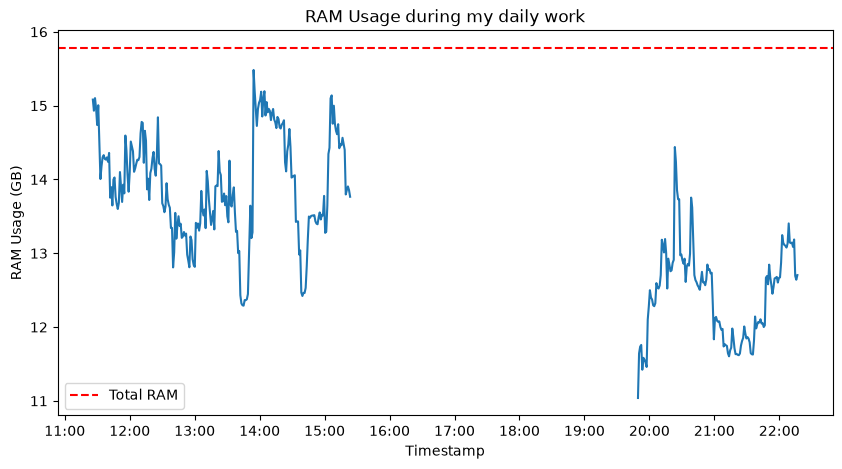

In [17]:
generate_plot("test_ram_usage_24062026.csv")

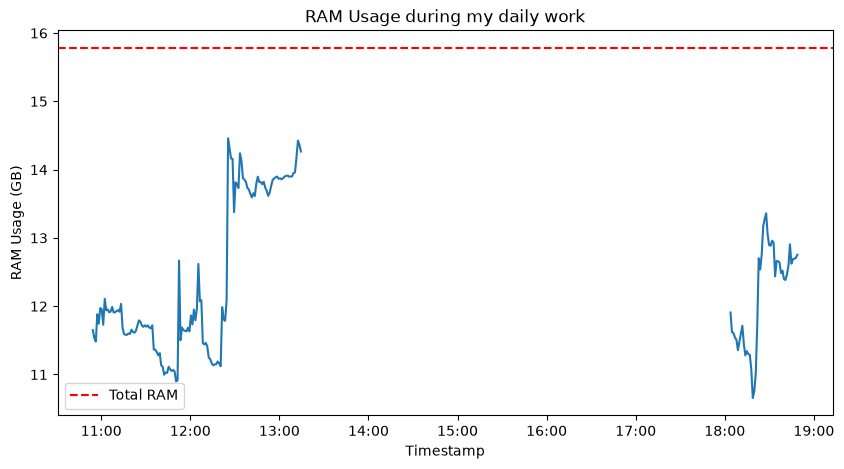

In [18]:
generate_plot("test_ram_usage_25062026.csv")

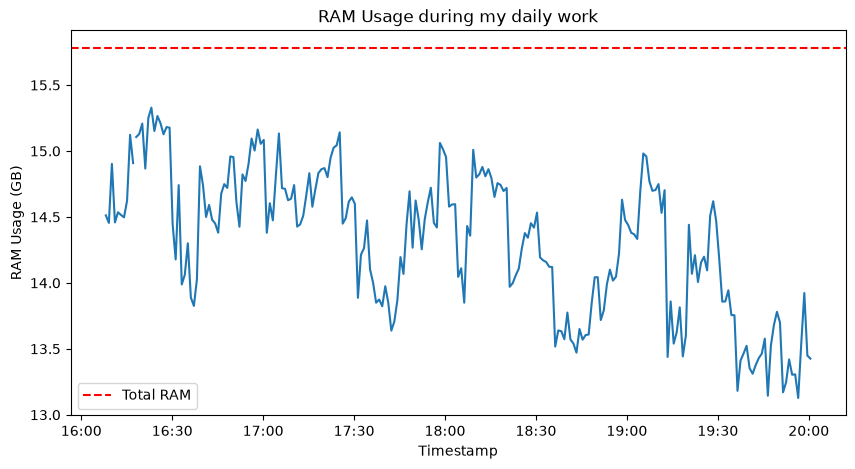

In [19]:
generate_plot("test_ram_usage_26062026.csv")

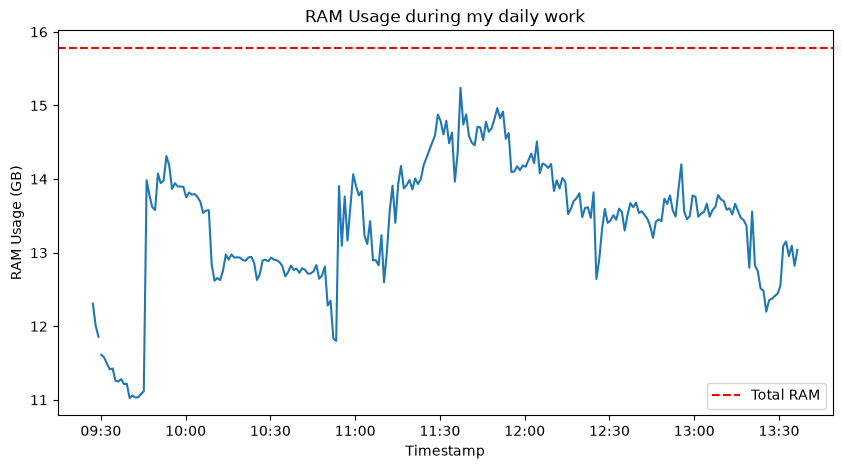

In [20]:
generate_plot("test_ram_usage_29062026.csv")